# Imports

In [1]:
import math
import os
import sys

import numpy as np
import torch
from torchvision.transforms import GaussianBlur
from IPython.core.pylabtools import figsize
from mpmath.identification import transforms
import matplotlib.pyplot as plt
from torchvision.transforms.v2 import RandomApply

from utils.checkpoint import load_checkpoint, save_checkpoint
from utils.data import get_dataloaders, get_img_from_loader
from evaluate import evaluate, evaluate_with_uncertainty

sys.path.append("..")

from models.lenet import Net as LeNet
from config import Config

from utils.corruptions import gaussian_blur, test_on_corruptions, corruptions_uncertainty
from utils.data import get_img_from_loader



In [2]:
torch.manual_seed(42)

config = Config()
device = config.device
T = 10

# Model
mnist_model = LeNet(
    prior_sigma1=math.exp(0),
    prior_sigma2=math.exp(-6),
    prior_pi=0.5,
    num_classes=10,
    rho_init=-4.5
).to(device)

emnist_model = LeNet(
    prior_sigma1=math.exp(-0.8470609173270909),
    prior_sigma2=math.exp(-7.293222293379696),
    prior_pi=0.44622172885322486,
    num_classes=26,
    rho_init=-5.724956071835678
).to(device)

# Optimizer (needed to load checkpoint)
optimizer = torch.optim.Adam(emnist_model.parameters(), lr=config.learning_rate)
# Load weights
config.model_name = 'lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1'
load_checkpoint(emnist_model, None, f'{config.checkpoint_path}/{config.model_name}/{config.model_name}_20260317.pth', device)
config.model_name = 'lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1'
load_checkpoint(mnist_model, optimizer, f'{config.checkpoint_path}/{config.model_name}/{config.get_checkpoint_name(190, date="20260129")}', device)

[checkpoint] Loaded from ../checkpoints/lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1/lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1_20260317.pth, starting at epoch 61
[checkpoint] Loaded from ../checkpoints/lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1/lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1_epoch_190_20260129.pth, starting at epoch 191


191

# Вычисление точности с гауссовским размытием

In [ ]:
from tqdm import tqdm

kernel_sizes = [1, 3, 5, 7, 9]


## EMNIST-letters

In [11]:
accuracies = []
total_unc = []
alea_unc = []
epis_unc = []

loop = tqdm(kernel_sizes, desc=f"Calculating Accuracy and Uncertainties on EMNIST-letters dataset with Gaussian Blur")
for kernel_size in loop:
    blurred_test_loader = get_dataloaders(
        data_dir="../data",
        batch_size=config.test_batch_size,
        num_workers=config.num_workers,
        use_cuda=torch.cuda.is_available(),
        dataset="EMNIST",
        dataset_kwargs={"split": "letters"},
        extra_transforms=[
            GaussianBlur(kernel_size)
        ]
    )[2]  # Получаем только тестовый загрузчик

    test_accuracy = evaluate(emnist_model, blurred_test_loader, device=config.device)
    _, uncertainties = evaluate_with_uncertainty(emnist_model, blurred_test_loader, device=config.device, mc_samples=T)
    accuracies.append(test_accuracy)
    total_unc.append(uncertainties[0].mean().item())
    alea_unc.append(uncertainties[1].mean().item())
    epis_unc.append(uncertainties[2].mean().item())

Calculating Accuracy and Uncertainties on EMNIST-letters dataset with Gaussian Blur: 100%|██████████| 5/5 [09:13<00:00, 110.80s/it]


## MNIST

In [13]:
from tqdm import tqdm

mnist_accuracies = []
mnist_total_unc = []
mnist_alea_unc = []
mnist_epis_unc = []

loop = tqdm(kernel_sizes, desc=f"Calculating Accuracy and Uncertainties for MNIST dataset with Gaussian Blur")
for kernel_size in loop:
    blurred_test_loader = get_dataloaders(
        data_dir="../data",
        batch_size=config.test_batch_size,
        num_workers=config.num_workers,
        use_cuda=torch.cuda.is_available(),
        extra_transforms=[
            GaussianBlur(kernel_size)
        ]
    )[2]  # Получаем только тестовый загрузчик

    test_accuracy = evaluate(mnist_model, blurred_test_loader, device=config.device)
    _, uncertainties = evaluate_with_uncertainty(mnist_model, blurred_test_loader, device=config.device, mc_samples=T)
    mnist_accuracies.append(test_accuracy)
    mnist_total_unc.append(uncertainties[0].mean().item())
    mnist_alea_unc.append(uncertainties[1].mean().item())
    mnist_epis_unc.append(uncertainties[2].mean().item())

Calculating Accuracy and Uncertainties for MNIST dataset with Gaussian Blur: 100%|██████████| 5/5 [04:39<00:00, 55.84s/it]


## Графики

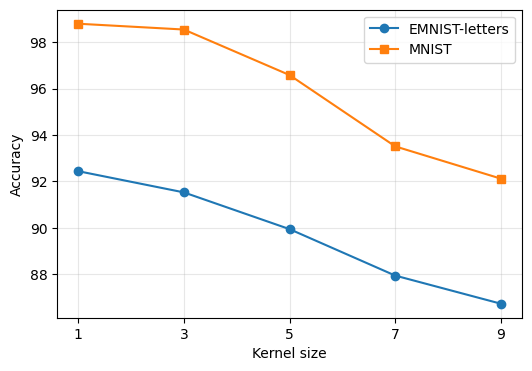

In [31]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = {'E': 'C0', 'M': 'C1'}

ax.plot(kernel_sizes, accuracies, color=colors['E'], label="EMNIST-letters", marker='o')
ax.plot(kernel_sizes, mnist_accuracies, color=colors['M'], label="MNIST", marker='s')

ax.set_xticks(kernel_sizes)
ax.set_xlabel("Kernel size")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

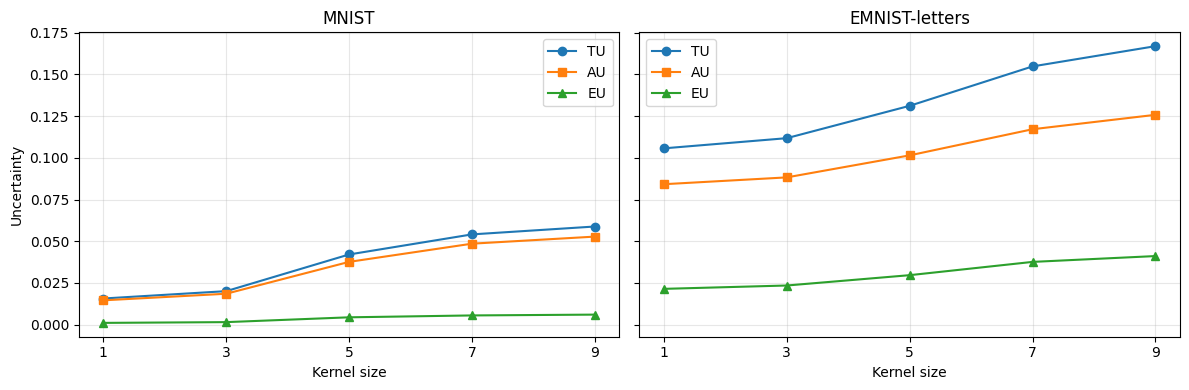

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

colors = {'TU': 'C0', 'AU': 'C1', 'EU': 'C2'}

# Левый subplot — MNIST
axes[0].plot(kernel_sizes, mnist_total_unc, label='TU', marker='o', color=colors['TU'])
axes[0].plot(kernel_sizes, mnist_alea_unc,  label='AU', marker='s', color=colors['AU'])
axes[0].plot(kernel_sizes, mnist_epis_unc,  label='EU', marker='^', color=colors['EU'])
axes[0].set_title('MNIST')
axes[0].set_xlabel('Kernel size')
axes[0].set_ylabel('Uncertainty')
axes[0].set_xticks(kernel_sizes)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Правый subplot — EMNIST-letters
axes[1].plot(kernel_sizes, total_unc, label='TU', marker='o', color=colors['TU'])
axes[1].plot(kernel_sizes, alea_unc,  label='AU', marker='s', color=colors['AU'])
axes[1].plot(kernel_sizes, epis_unc,  label='EU', marker='^', color=colors['EU'])
axes[1].set_title('EMNIST-letters')
axes[1].set_xlabel('Kernel size')
axes[1].set_xticks(kernel_sizes)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


# Зависимость неопределенности модели от правильности предсказаний

In [3]:
# Анализ корреляции между неопределенностью и правильностью предсказаний для разных уровней размытия
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.transforms import GaussianBlur
from utils.uncertainty import mc_predict, quantify_uncertainties

T = 10
kernel_sizes = [1, 3, 5, 7, 9]

## EMNIST-letters

In [4]:
emnist_correlations_pred = []
emnist_correlations_true = []
emnist_mean_unc_correct = []
emnist_mean_unc_incorrect = []
emnist_mean_aunc_correct = []
emnist_mean_aunc_incorrect = []
emnist_mean_eunc_correct = []
emnist_mean_eunc_incorrect = []

for ks in kernel_sizes:
    current_loader = get_dataloaders(
        data_dir="../data",
        batch_size=config.test_batch_size,
        num_workers=config.num_workers,
        use_cuda=torch.cuda.is_available(),
        dataset="EMNIST",
        dataset_kwargs={"split": "letters"},
        extra_transforms=[GaussianBlur(ks)]
    )[2]

    all_correct, all_pred_conf, all_true_conf = [], [], []
    all_uncertainties, all_aleatoric, all_epistemic = [], [], []

    print(f"Processing Blur {ks}...")
    for x, y in tqdm(current_loader, leave=False):
        x, y = x.to(device), y.to(device)

        mc_preds = mc_predict(emnist_model, x, mc_samples=T)
        preds, (total_unc_mat, alea_unc_mat, _) = quantify_uncertainties(mc_preds)

        unc = total_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)
        aunc = alea_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)

        mean_probs = mc_preds.mean(0)
        pred_conf = mean_probs[torch.arange(len(preds)), preds]
        true_conf = mean_probs[torch.arange(len(y)), y]

        all_correct.append((preds == y).float().cpu().numpy())
        all_pred_conf.append(pred_conf.cpu().numpy())
        all_true_conf.append(true_conf.cpu().numpy())
        all_uncertainties.append(unc.cpu().numpy())
        all_aleatoric.append(aunc.cpu().numpy())
        all_epistemic.append((unc - aunc).cpu().numpy())

    c_vec = np.concatenate(all_correct)
    u_vec = np.concatenate(all_uncertainties)
    au_vec = np.concatenate(all_aleatoric)
    eu_vec = np.concatenate(all_epistemic)

    print(f"Kernel {ks}: E[epistemic]={eu_vec.mean():.6f}, E[aleatoric]={au_vec.mean():.6f}, ratio={eu_vec.mean()/au_vec.mean():.4f}")

    emnist_correlations_pred.append(np.corrcoef(np.concatenate(all_pred_conf), u_vec)[0, 1])
    emnist_correlations_true.append(np.corrcoef(np.concatenate(all_true_conf), u_vec)[0, 1])

    emnist_mean_unc_correct.append(u_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    emnist_mean_unc_incorrect.append(u_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    emnist_mean_aunc_correct.append(au_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    emnist_mean_aunc_incorrect.append(au_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    emnist_mean_eunc_correct.append(eu_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    emnist_mean_eunc_incorrect.append(eu_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)

Processing Blur 1...


Kernel 1: E[epistemic]=0.022083, E[aleatoric]=0.084416, ratio=0.2616
Processing Blur 3...


Kernel 3: E[epistemic]=0.023428, E[aleatoric]=0.088308, ratio=0.2653
Processing Blur 5...


Kernel 5: E[epistemic]=0.030000, E[aleatoric]=0.102165, ratio=0.2936
Processing Blur 7...


Kernel 7: E[epistemic]=0.038250, E[aleatoric]=0.118338, ratio=0.3232
Processing Blur 9...


Kernel 9: E[epistemic]=0.041815, E[aleatoric]=0.126007, ratio=0.3318


## MNIST

In [5]:
mnist_correlations_pred = []
mnist_correlations_true = []
mnist_mean_unc_correct = []
mnist_mean_unc_incorrect = []
mnist_mean_aunc_correct = []
mnist_mean_aunc_incorrect = []
mnist_mean_eunc_correct = []
mnist_mean_eunc_incorrect = []

for ks in kernel_sizes:
    current_loader = get_dataloaders(
        data_dir="../data",
        batch_size=config.test_batch_size,
        num_workers=config.num_workers,
        use_cuda=torch.cuda.is_available(),
        extra_transforms=[GaussianBlur(ks)]
    )[2]

    all_correct, all_pred_conf, all_true_conf = [], [], []
    all_uncertainties, all_aleatoric, all_epistemic = [], [], []

    print(f"Processing Blur {ks}...")
    for x, y in tqdm(current_loader, leave=False):
        x, y = x.to(device), y.to(device)

        mc_preds = mc_predict(mnist_model, x, mc_samples=T)
        preds, (total_unc_mat, alea_unc_mat, _) = quantify_uncertainties(mc_preds)

        unc = total_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)
        aunc = alea_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)

        mean_probs = mc_preds.mean(0)
        pred_conf = mean_probs[torch.arange(len(preds)), preds]
        true_conf = mean_probs[torch.arange(len(y)), y]

        all_correct.append((preds == y).float().cpu().numpy())
        all_pred_conf.append(pred_conf.cpu().numpy())
        all_true_conf.append(true_conf.cpu().numpy())
        all_uncertainties.append(unc.cpu().numpy())
        all_aleatoric.append(aunc.cpu().numpy())
        all_epistemic.append((unc - aunc).cpu().numpy())

    c_vec = np.concatenate(all_correct)
    u_vec = np.concatenate(all_uncertainties)
    au_vec = np.concatenate(all_aleatoric)
    eu_vec = np.concatenate(all_epistemic)

    print(f"Kernel {ks}: E[epistemic]={eu_vec.mean():.6f}, E[aleatoric]={au_vec.mean():.6f}, ratio={eu_vec.mean()/au_vec.mean():.4f}")

    mnist_correlations_pred.append(np.corrcoef(np.concatenate(all_pred_conf), u_vec)[0, 1])
    mnist_correlations_true.append(np.corrcoef(np.concatenate(all_true_conf), u_vec)[0, 1])

    mnist_mean_unc_correct.append(u_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mnist_mean_unc_incorrect.append(u_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    mnist_mean_aunc_correct.append(au_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mnist_mean_aunc_incorrect.append(au_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    mnist_mean_eunc_correct.append(eu_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mnist_mean_eunc_incorrect.append(eu_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)

Processing Blur 1...


Kernel 1: E[epistemic]=0.001137, E[aleatoric]=0.014571, ratio=0.0780
Processing Blur 3...


Kernel 3: E[epistemic]=0.001619, E[aleatoric]=0.018849, ratio=0.0859
Processing Blur 5...


Kernel 5: E[epistemic]=0.004246, E[aleatoric]=0.035991, ratio=0.1180
Processing Blur 7...


Kernel 7: E[epistemic]=0.005785, E[aleatoric]=0.049881, ratio=0.1160
Processing Blur 9...


Kernel 9: E[epistemic]=0.006034, E[aleatoric]=0.052973, ratio=0.1139


## Графики

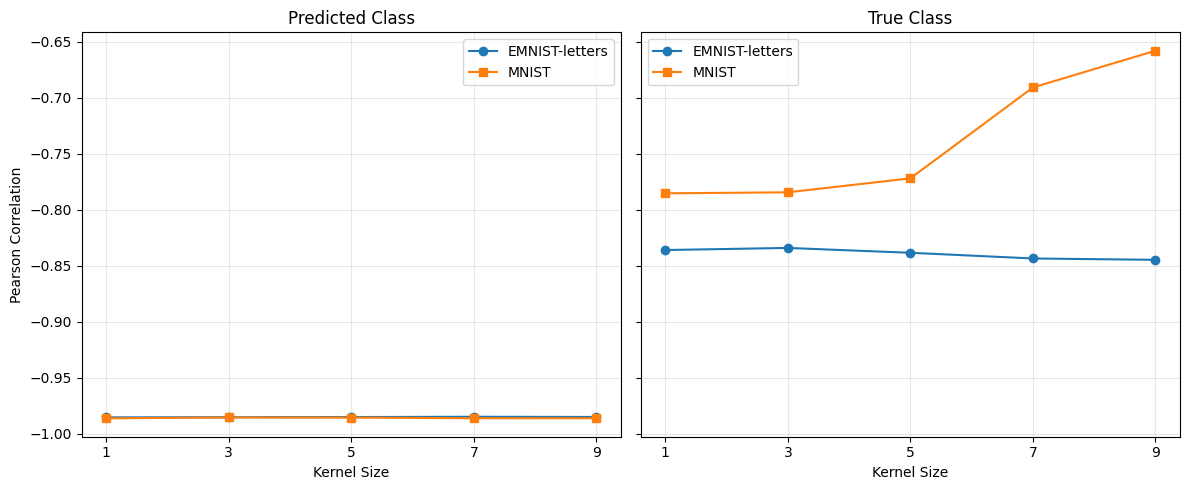

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = {'E': 'C0', 'M': 'C1'}
markers = {'E': 'o', 'M': 's'}

# Левый subplot — pred_conf
axes[0].plot(kernel_sizes, emnist_correlations_pred, marker=markers['E'], color=colors['E'], label='EMNIST-letters')
axes[0].plot(kernel_sizes, mnist_correlations_pred, marker=markers['M'], color=colors['M'], label='MNIST')
axes[0].set_title('Predicted Class')
axes[0].set_xticks(kernel_sizes)
axes[0].set_xlabel("Kernel Size")
axes[0].set_ylabel("Pearson Correlation")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Правый subplot — true_conf
axes[1].plot(kernel_sizes, emnist_correlations_true, marker=markers['E'], color=colors['E'], label='EMNIST-letters')
axes[1].plot(kernel_sizes, mnist_correlations_true, marker=markers['M'], color=colors['M'], label='MNIST')
axes[1].set_title('True Class')
axes[1].set_xticks(kernel_sizes)
axes[1].set_xlabel("Kernel Size")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

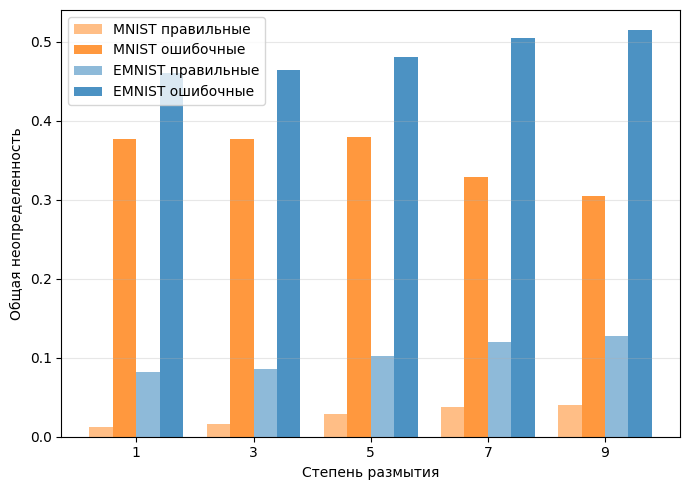

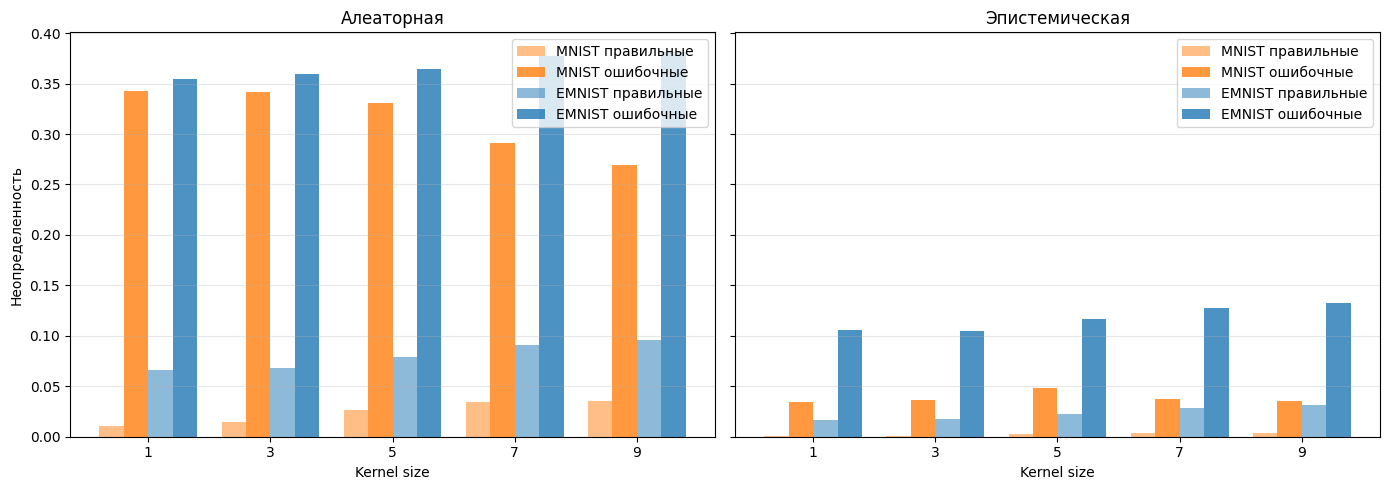

In [12]:
x = np.arange(len(kernel_sizes))
x_labels = [str(k) for k in kernel_sizes]
width = 0.2
colors = {'E': 'C0', 'M': 'C1'}

# Total — отдельный график
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - 1.5*width, mnist_mean_unc_correct,   width, label='MNIST правильные',    color=colors['M'], alpha=0.5)
ax.bar(x - 0.5*width, mnist_mean_unc_incorrect,  width, label='MNIST ошибочные',  color=colors['M'], alpha=0.8)
ax.bar(x + 0.5*width, emnist_mean_unc_correct,   width, label='EMNIST правильные',   color=colors['E'], alpha=0.5)
ax.bar(x + 1.5*width, emnist_mean_unc_incorrect,  width, label='EMNIST ошибочные', color=colors['E'], alpha=0.8)
ax.set_xlabel('Степень размытия')
ax.set_ylabel('Общая неопределенность')
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Aleatoric + Epistemic — один график с sharey=True
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, title, m_c, m_i, e_c, e_i in [
    (axes[0], 'Алеаторная', mnist_mean_aunc_correct, mnist_mean_aunc_incorrect,
     emnist_mean_aunc_correct, emnist_mean_aunc_incorrect),
    (axes[1], 'Эпистемическая', mnist_mean_eunc_correct, mnist_mean_eunc_incorrect,
     emnist_mean_eunc_correct, emnist_mean_eunc_incorrect),
]:
    ax.bar(x - 1.5*width, m_c, width, label='MNIST правильные',    color=colors['M'], alpha=0.5)
    ax.bar(x - 0.5*width, m_i, width, label='MNIST ошибочные',  color=colors['M'], alpha=0.8)
    ax.bar(x + 0.5*width, e_c, width, label='EMNIST правильные',   color=colors['E'], alpha=0.5)
    ax.bar(x + 1.5*width, e_i, width, label='EMNIST ошибочные', color=colors['E'], alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Kernel size')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Неопределенность')
plt.tight_layout()
plt.show()

# Зависимость неопределенности от уровня и типа искажений

In [7]:
corruptions = {
    'Original': lambda x: x,
    # 'WeakBlur': lambda x: gaussian_blur(x, kernel_size=3),
    'MediumBlur': lambda x: gaussian_blur(x, kernel_size=5),
    # 'StrongBlur': lambda x: gaussian_blur(x, kernel_size=7),
    'VeryStrongBlur': lambda x: gaussian_blur(x, kernel_size=9),
}

In [5]:
# Prepare data
_, _, test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
    dataset='EMNIST',
    dataset_kwargs={"split": "letters"},
)

letters_map = {i: chr(97 + i) for i in range(26)}

Random batch index: 1121, image index: 7
IMG[1121, 7]=t


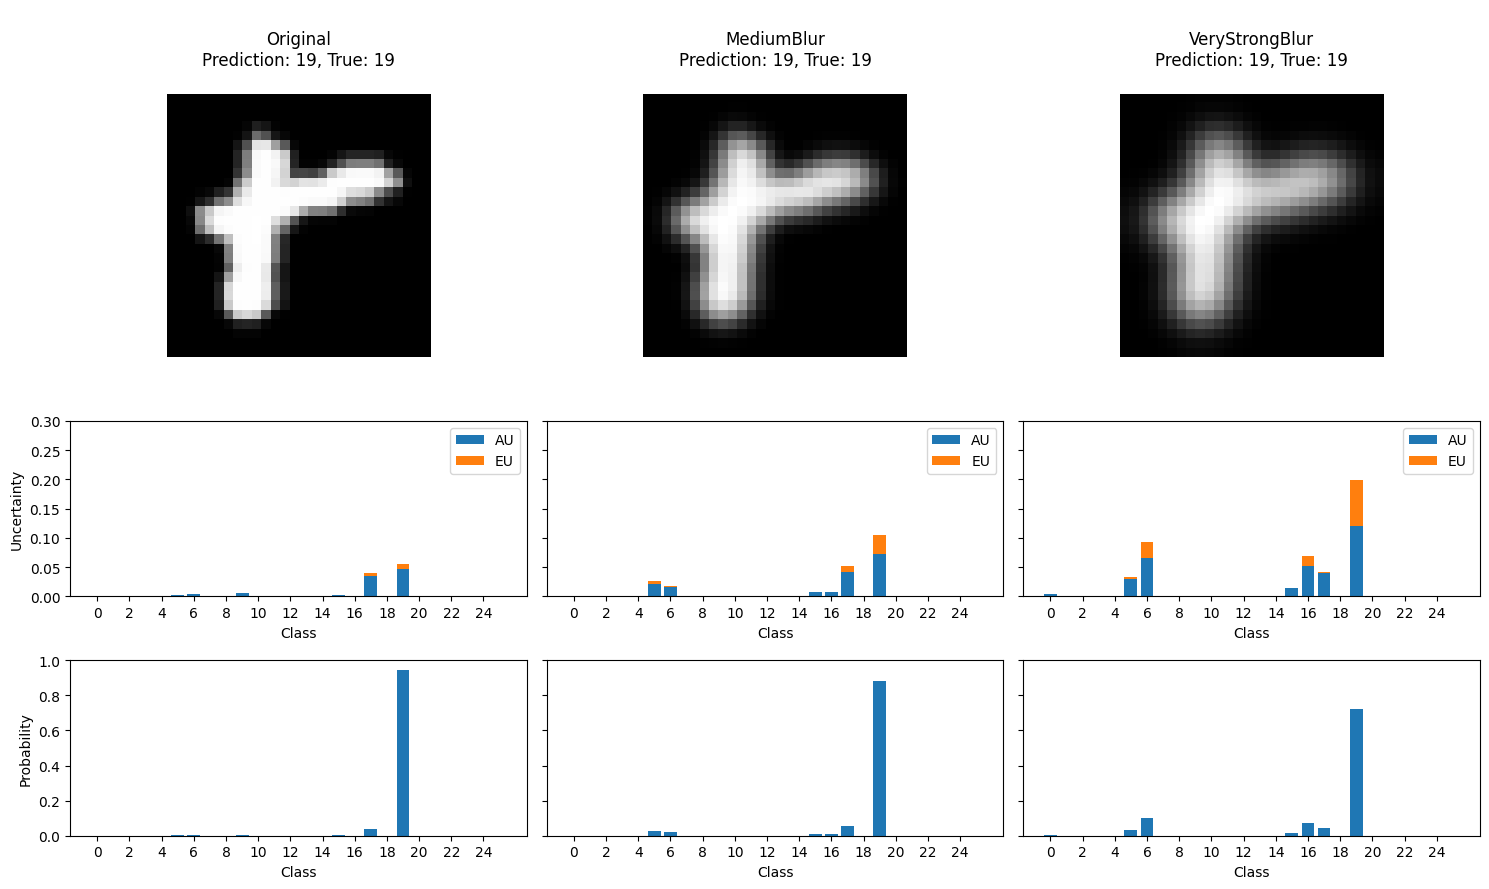

In [10]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
print(f'IMG[{rand_batch_idx}, {rand_img_idx}]={letters_map[label.item()]}')
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, mc_samples=T)

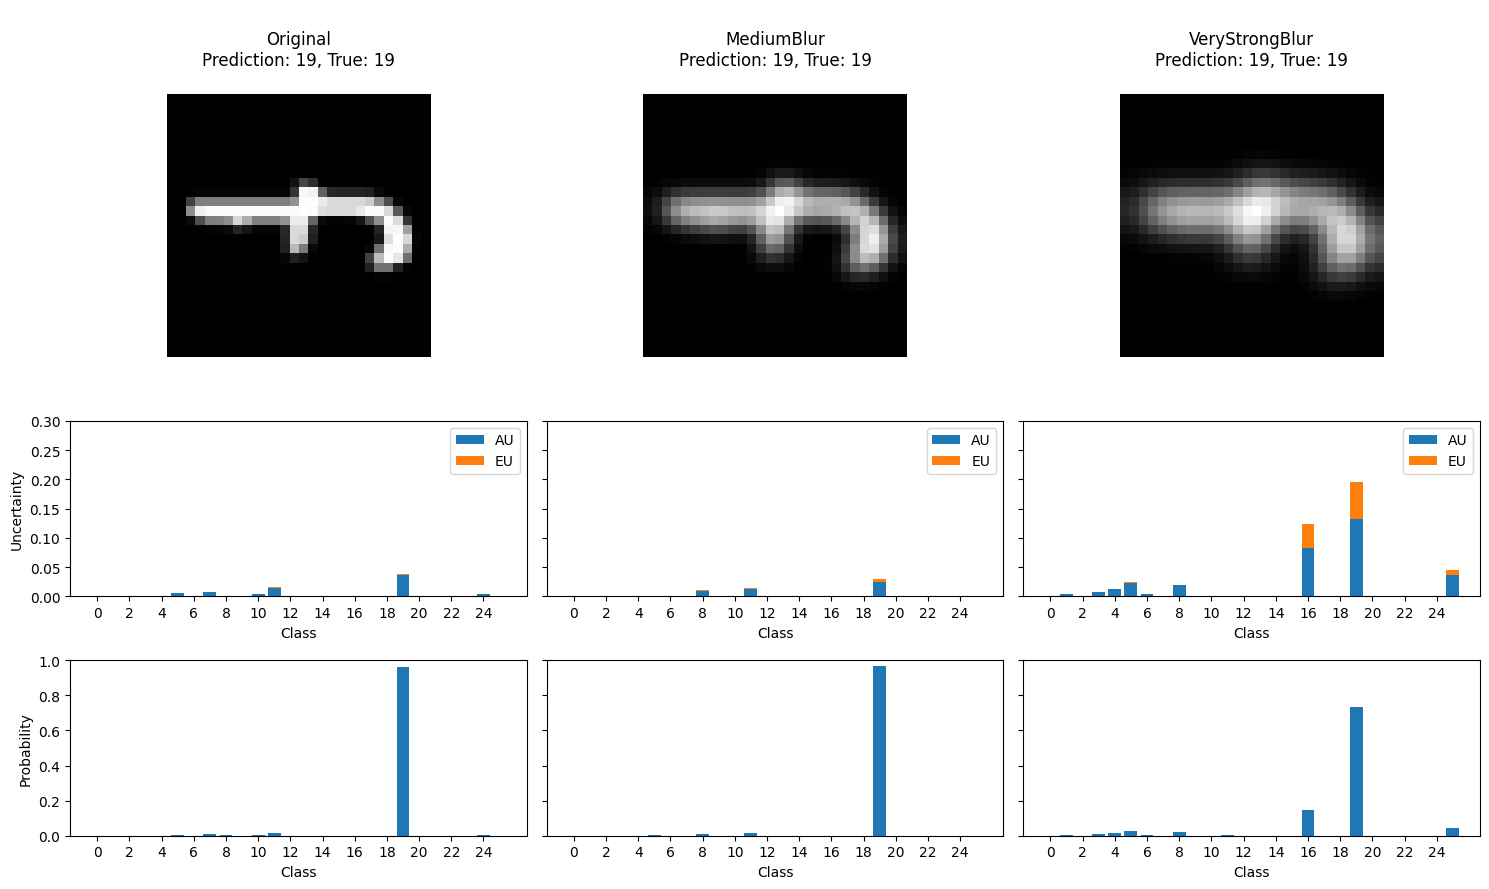

In [12]:
img, label = get_img_from_loader(test_loader, batch_idx=1089, img_idx=2, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, mc_samples=T)

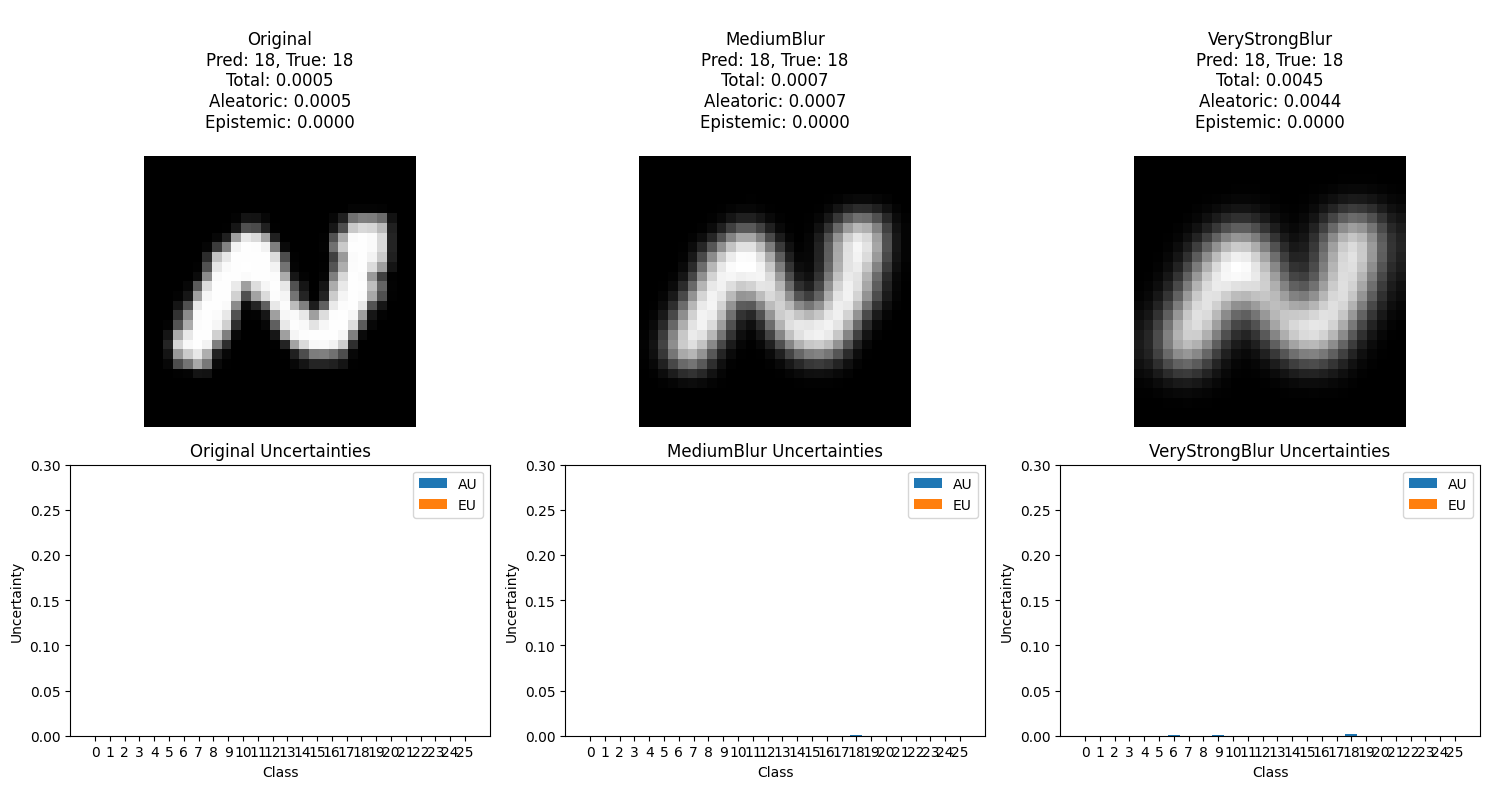

In [12]:
img, label = get_img_from_loader(test_loader, batch_idx=1036, img_idx=9, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

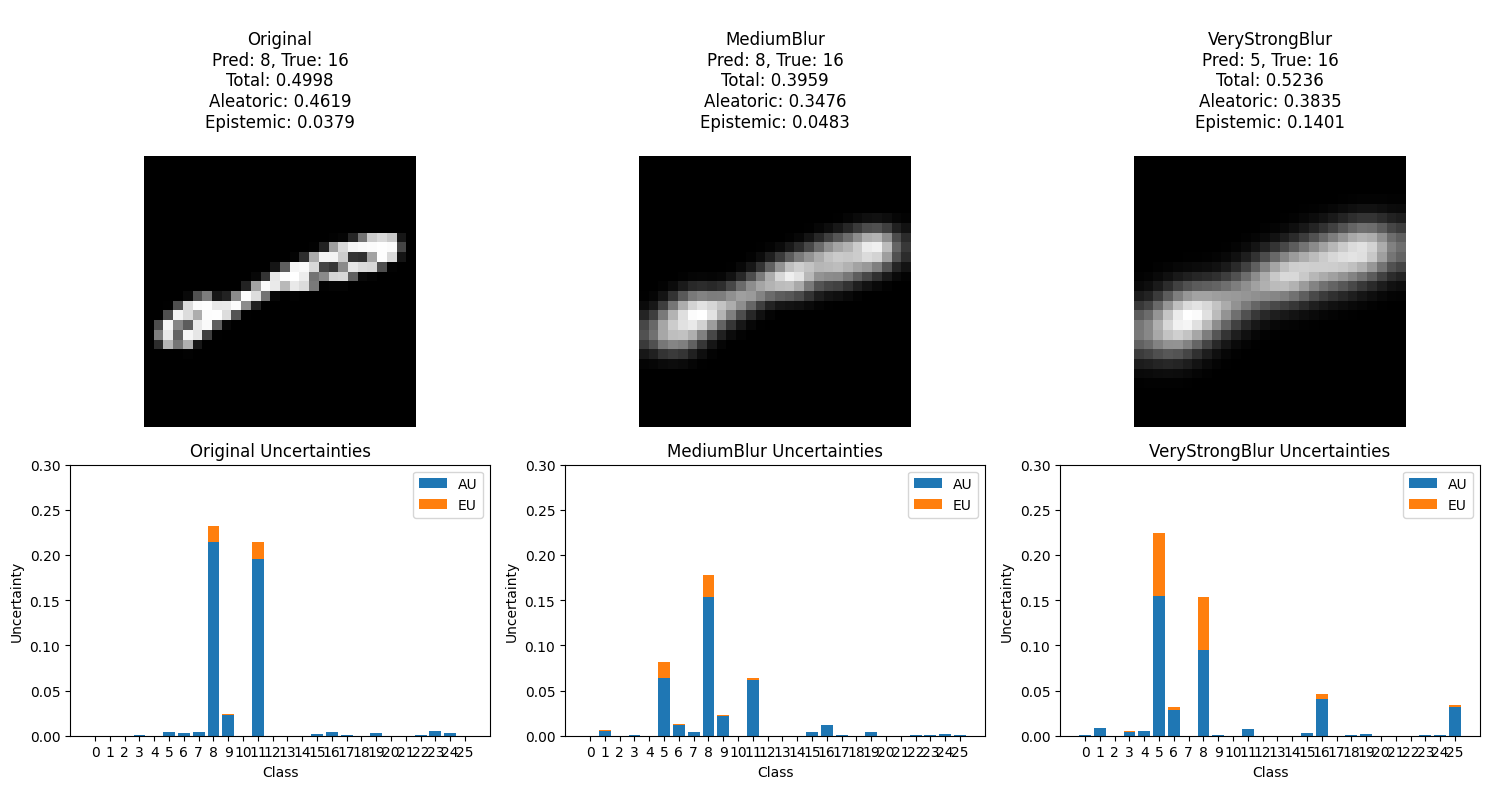

In [6]:
img, label = get_img_from_loader(test_loader, batch_idx=965, img_idx=1, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

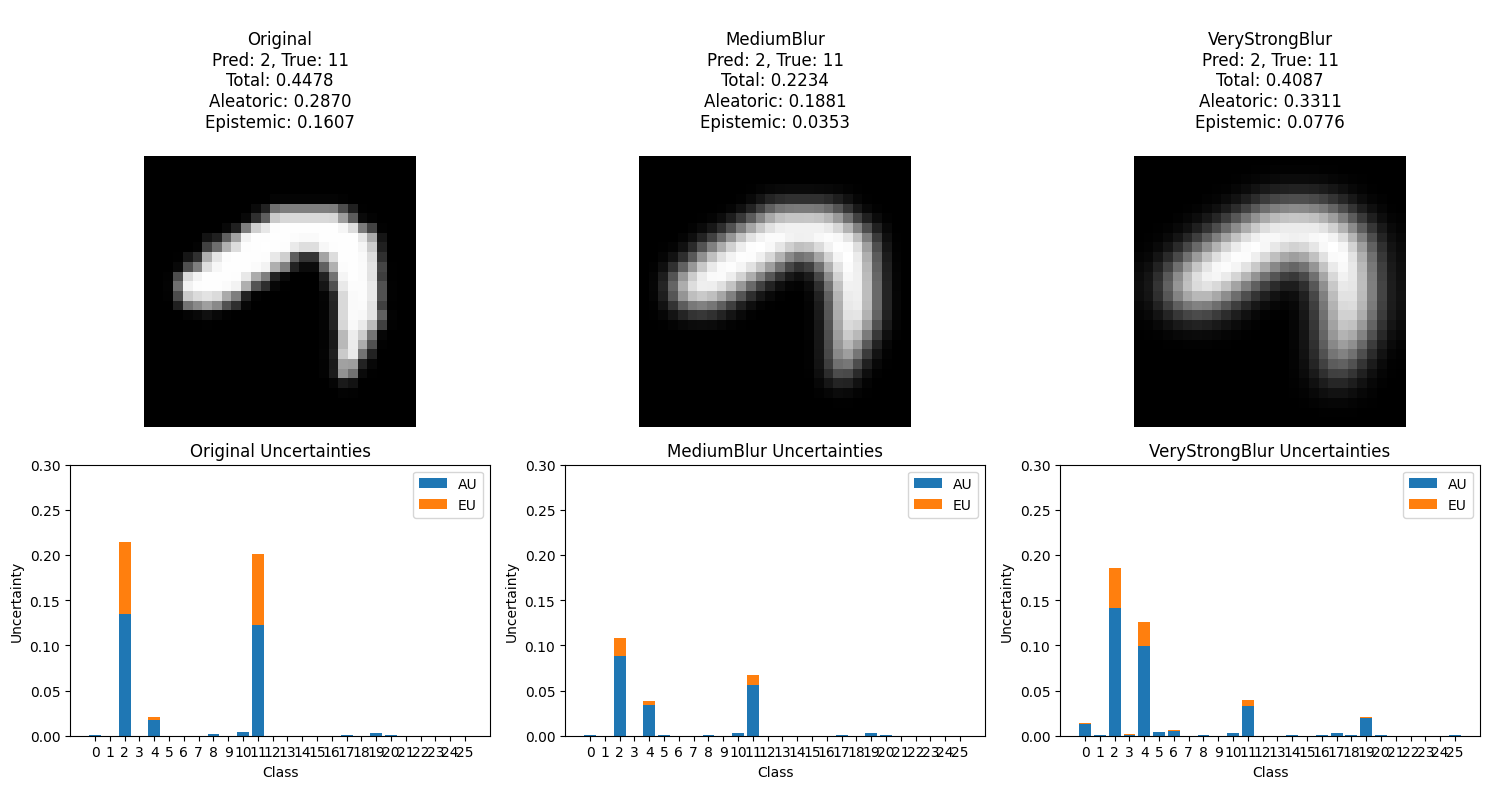

In [7]:
img, label = get_img_from_loader(test_loader, batch_idx=677, img_idx=10, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

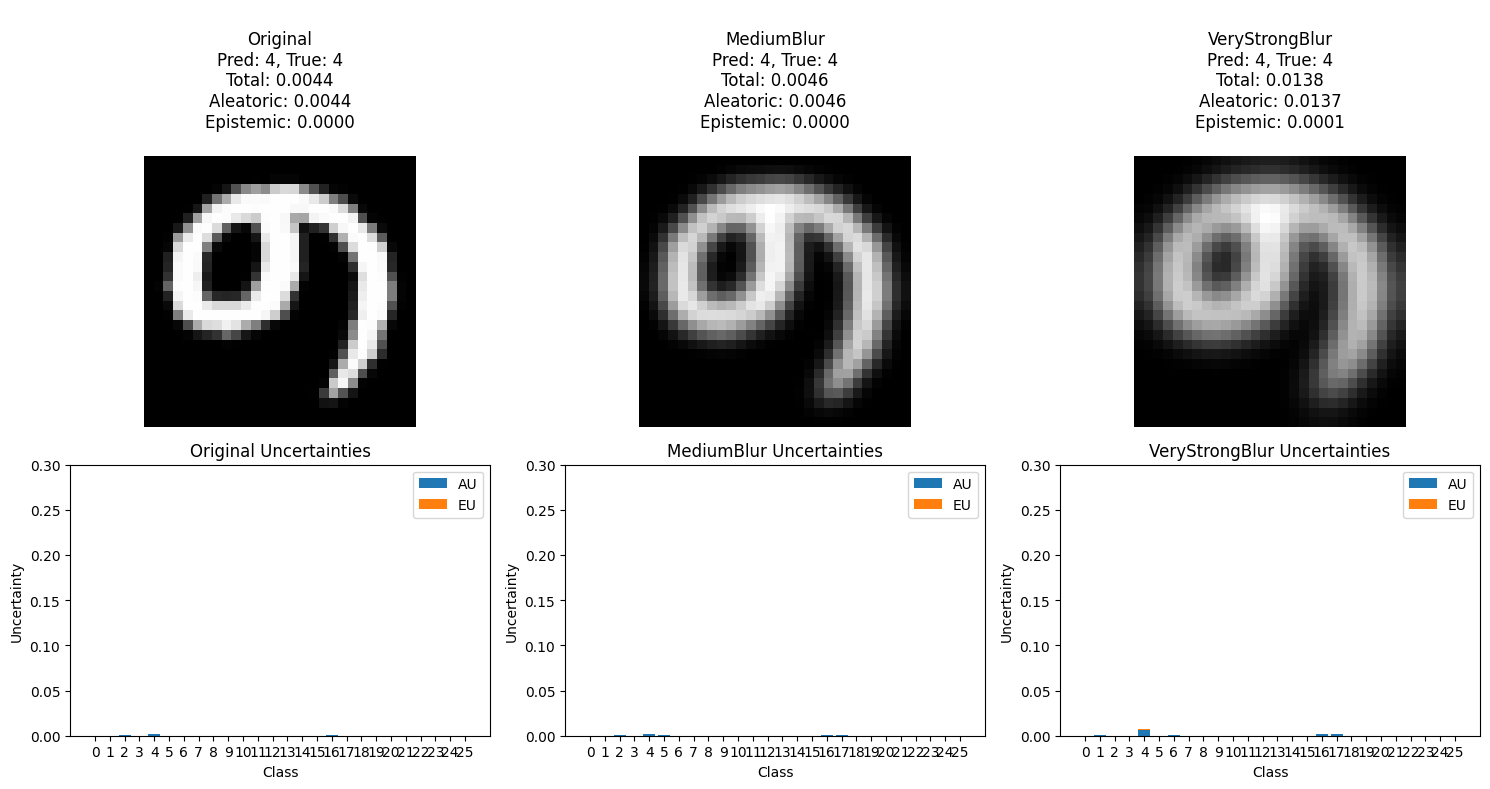

In [8]:
img, label = get_img_from_loader(test_loader, batch_idx=285, img_idx=5, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

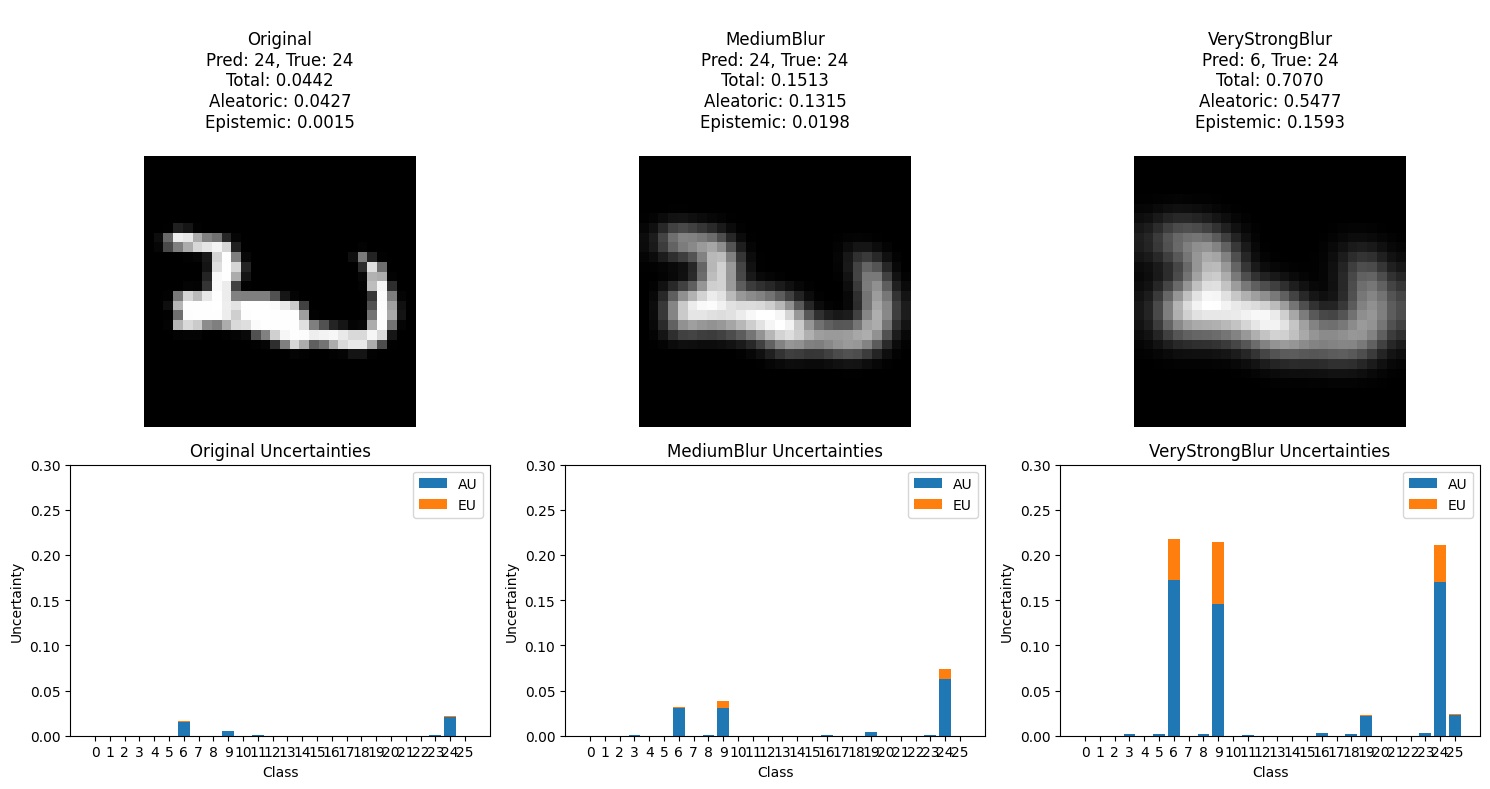

In [9]:
img, label = get_img_from_loader(test_loader, batch_idx=1394, img_idx=12, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

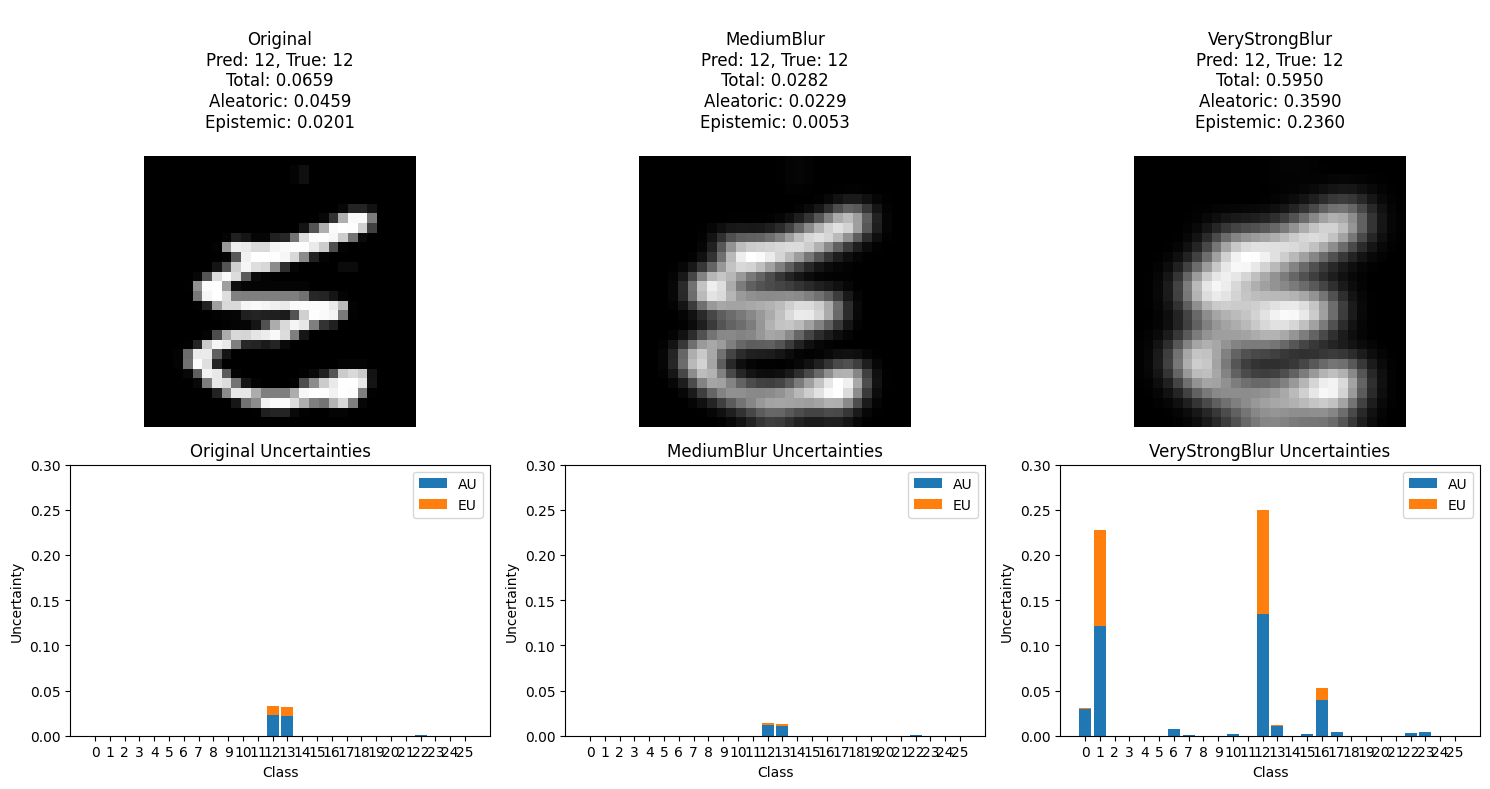

In [10]:
img, label = get_img_from_loader(test_loader, batch_idx=717, img_idx=1, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

# AUROC: эпистемическая неопределённость как детектор ошибок

In [13]:
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from torchvision.transforms import GaussianBlur
from utils.uncertainty import mc_predict, quantify_uncertainties

T = 10
kernel_sizes = [1, 3, 5, 7, 9]

emnist_aurocs = []
mnist_aurocs = []

# --- EMNIST ---
for ks in kernel_sizes:
    loader = get_dataloaders(
        data_dir="../data", batch_size=config.test_batch_size,
        num_workers=config.num_workers, use_cuda=torch.cuda.is_available(),
        dataset="EMNIST", dataset_kwargs={"split": "letters"},
        extra_transforms=[GaussianBlur(ks)]
    )[2]

    all_eu, all_wrong = [], []
    for x, y in tqdm(loader, desc=f"EMNIST blur={ks}", leave=False):
        x, y = x.to(device), y.to(device)
        mc_preds = mc_predict(emnist_model, x, mc_samples=T)
        preds, (tu, au, _) = quantify_uncertainties(mc_preds)
        eu = (tu - au).diagonal(dim1=1, dim2=2).sum(-1)
        all_eu.append(eu.cpu().numpy())
        all_wrong.append((preds != y).cpu().numpy().astype(int))

    eu_vec = np.concatenate(all_eu)
    wrong_vec = np.concatenate(all_wrong)
    auroc = roc_auc_score(wrong_vec, eu_vec)
    emnist_aurocs.append(auroc)
    print(f"EMNIST  blur={ks}: AUROC = {auroc:.4f}")

# --- MNIST ---
for ks in kernel_sizes:
    loader = get_dataloaders(
        data_dir="../data", batch_size=config.test_batch_size,
        num_workers=config.num_workers, use_cuda=torch.cuda.is_available(),
        extra_transforms=[GaussianBlur(ks)]
    )[2]

    all_eu, all_wrong = [], []
    for x, y in tqdm(loader, desc=f"MNIST blur={ks}", leave=False):
        x, y = x.to(device), y.to(device)
        mc_preds = mc_predict(mnist_model, x, mc_samples=T)
        preds, (tu, au, _) = quantify_uncertainties(mc_preds)
        eu = (tu - au).diagonal(dim1=1, dim2=2).sum(-1)
        all_eu.append(eu.cpu().numpy())
        all_wrong.append((preds != y).cpu().numpy().astype(int))

    eu_vec = np.concatenate(all_eu)
    wrong_vec = np.concatenate(all_wrong)
    auroc = roc_auc_score(wrong_vec, eu_vec)
    mnist_aurocs.append(auroc)
    print(f"MNIST   blur={ks}: AUROC = {auroc:.4f}")

print("\n--- Summary ---")
for ks, ea, ma in zip(kernel_sizes, emnist_aurocs, mnist_aurocs):
    print(f"Kernel {ks}: EMNIST AUROC={ea:.4f}, MNIST AUROC={ma:.4f}")

EMNIST  blur=1: AUROC = 0.8997


EMNIST  blur=3: AUROC = 0.8914


EMNIST  blur=5: AUROC = 0.8801


EMNIST  blur=7: AUROC = 0.8718


EMNIST  blur=9: AUROC = 0.8685


MNIST   blur=1: AUROC = 0.9854


MNIST   blur=3: AUROC = 0.9792


MNIST   blur=5: AUROC = 0.9538


MNIST   blur=7: AUROC = 0.9301


MNIST   blur=9: AUROC = 0.9207

--- Summary ---
Kernel 1: EMNIST AUROC=0.8997, MNIST AUROC=0.9854
Kernel 3: EMNIST AUROC=0.8914, MNIST AUROC=0.9792
Kernel 5: EMNIST AUROC=0.8801, MNIST AUROC=0.9538
Kernel 7: EMNIST AUROC=0.8718, MNIST AUROC=0.9301
Kernel 9: EMNIST AUROC=0.8685, MNIST AUROC=0.9207


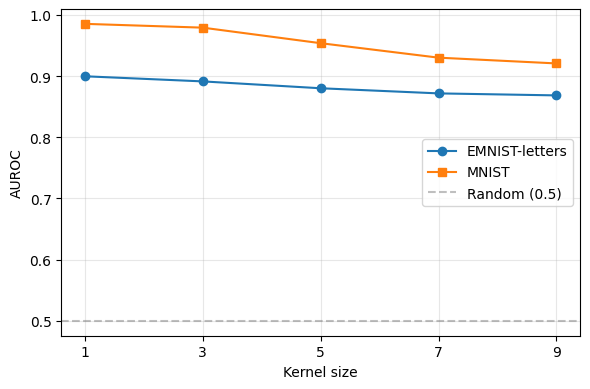

In [15]:
colors = {'E': 'C0', 'M': 'C1'}
markers = {'E': 'o', 'M': 's'}
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(kernel_sizes, emnist_aurocs, marker=markers['E'], color=colors['E'], label='EMNIST-letters')
ax.plot(kernel_sizes, mnist_aurocs, marker=markers['M'], color=colors['M'], label='MNIST')
ax.axhline(0.5, ls='--', color='gray', alpha=0.5, label='Random (0.5)')
ax.set_xticks(kernel_sizes)
ax.set_xlabel('Kernel size')
ax.set_ylabel('AUROC')
# ax.set_title('Epistemic Uncertainty as Error Detector')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from utils.uncertainty import mc_predict, quantify_uncertainties

T = 10

# --- EMNIST ---
emnist_test_loader = get_dataloaders(
    data_dir="../data", batch_size=config.test_batch_size,
    num_workers=config.num_workers, use_cuda=torch.cuda.is_available(),
    dataset="EMNIST", dataset_kwargs={"split": "letters"},
)[2]

all_tu, all_au, all_eu, all_wrong = [], [], [], []
for x, y in tqdm(emnist_test_loader, desc="EMNIST"):
    x, y = x.to(device), y.to(device)
    mc_preds = mc_predict(emnist_model, x, mc_samples=T)
    preds, (tu, au, _) = quantify_uncertainties(mc_preds)
    all_tu.append(tu.diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy())
    all_au.append(au.diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy())
    all_eu.append((tu - au).diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy())
    all_wrong.append((preds != y).cpu().numpy().astype(int))

emnist_wrong = np.concatenate(all_wrong)
emnist_auroc_tu = roc_auc_score(emnist_wrong, np.concatenate(all_tu))
emnist_auroc_au = roc_auc_score(emnist_wrong, np.concatenate(all_au))
emnist_auroc_eu = roc_auc_score(emnist_wrong, np.concatenate(all_eu))
print(f"EMNIST  AUROC — Total: {emnist_auroc_tu:.4f}, Aleatoric: {emnist_auroc_au:.4f}, Epistemic: {emnist_auroc_eu:.4f}")

# --- MNIST ---
mnist_test_loader = get_dataloaders(
    data_dir="../data", batch_size=config.test_batch_size,
    num_workers=config.num_workers, use_cuda=torch.cuda.is_available(),
)[2]

all_tu, all_au, all_eu, all_wrong = [], [], [], []
for x, y in tqdm(mnist_test_loader, desc="MNIST"):
    x, y = x.to(device), y.to(device)
    mc_preds = mc_predict(mnist_model, x, mc_samples=T)
    preds, (tu, au, _) = quantify_uncertainties(mc_preds)
    all_tu.append(tu.diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy())
    all_au.append(au.diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy())
    all_eu.append((tu - au).diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy())
    all_wrong.append((preds != y).cpu().numpy().astype(int))

mnist_wrong = np.concatenate(all_wrong)
mnist_auroc_tu = roc_auc_score(mnist_wrong, np.concatenate(all_tu))
mnist_auroc_au = roc_auc_score(mnist_wrong, np.concatenate(all_au))
mnist_auroc_eu = roc_auc_score(mnist_wrong, np.concatenate(all_eu))
print(f"MNIST   AUROC — Total: {mnist_auroc_tu:.4f}, Aleatoric: {mnist_auroc_au:.4f}, Epistemic: {mnist_auroc_eu:.4f}")

EMNIST: 100%|██████████| 1486/1486 [01:51<00:00, 13.29it/s]


EMNIST  AUROC — Total: 0.9301, Aleatoric: 0.9287, Epistemic: 0.8989


MNIST: 100%|██████████| 715/715 [00:50<00:00, 14.22it/s]

MNIST   AUROC — Total: 0.9883, Aleatoric: 0.9882, Epistemic: 0.9869


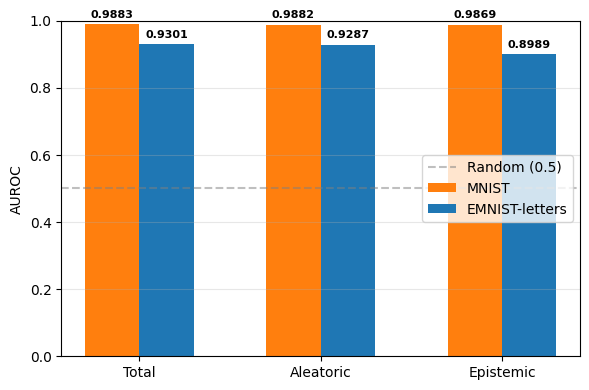

In [44]:
x = np.arange(3)
labels = ['Total', 'Aleatoric', 'Epistemic']
width = 0.3

mnist_vals = [mnist_auroc_tu, mnist_auroc_au, mnist_auroc_eu]
emnist_vals = [emnist_auroc_tu, emnist_auroc_au, emnist_auroc_eu]

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, mnist_vals, width, label='MNIST', color='C1')
bars2 = ax.bar(x + width/2, emnist_vals, width, label='EMNIST-letters', color='C0')
ax.axhline(0.5, ls='--', color='gray', alpha=0.5, label='Random (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('AUROC')
# ax.set_title('Uncertainty as Error Detector')
ax.set_ylim(0, 1)
ax.legend(loc='center right')
ax.grid(True, axis='y', alpha=0.3)
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.4f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

In [45]:
kernel_sizes = [1, 3, 5, 7, 9]

emnist_aurocs_tu, emnist_aurocs_au, emnist_aurocs_eu = [], [], []
mnist_aurocs_tu, mnist_aurocs_au, mnist_aurocs_eu = [], [], []

# --- EMNIST ---
for ks in kernel_sizes:
    loader = get_dataloaders(
        data_dir="../data", batch_size=config.test_batch_size,
        num_workers=config.num_workers, use_cuda=torch.cuda.is_available(),
        dataset="EMNIST", dataset_kwargs={"split": "letters"},
        extra_transforms=[GaussianBlur(ks)]
    )[2]

    all_tu, all_au, all_eu, all_wrong = [], [], [], []
    for x, y in tqdm(loader, desc=f"EMNIST blur={ks}", leave=False):
        x, y = x.to(device), y.to(device)
        mc_preds = mc_predict(emnist_model, x, mc_samples=T)
        preds, (tu, au, _) = quantify_uncertainties(mc_preds)
        all_tu.append(tu.diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy())
        all_au.append(au.diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy())
        all_eu.append((tu - au).diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy())
        all_wrong.append((preds != y).cpu().numpy().astype(int))

    wrong = np.concatenate(all_wrong)
    emnist_aurocs_tu.append(roc_auc_score(wrong, np.concatenate(all_tu)))
    emnist_aurocs_au.append(roc_auc_score(wrong, np.concatenate(all_au)))
    emnist_aurocs_eu.append(roc_auc_score(wrong, np.concatenate(all_eu)))
    print(f"EMNIST blur={ks}: TU={emnist_aurocs_tu[-1]:.4f}, AU={emnist_aurocs_au[-1]:.4f}, EU={emnist_aurocs_eu[-1]:.4f}")

# --- MNIST ---
for ks in kernel_sizes:
    loader = get_dataloaders(
        data_dir="../data", batch_size=config.test_batch_size,
        num_workers=config.num_workers, use_cuda=torch.cuda.is_available(),
        extra_transforms=[GaussianBlur(ks)]
    )[2]

    all_tu, all_au, all_eu, all_wrong = [], [], [], []
    for x, y in tqdm(loader, desc=f"MNIST blur={ks}", leave=False):
        x, y = x.to(device), y.to(device)
        mc_preds = mc_predict(mnist_model, x, mc_samples=T)
        preds, (tu, au, _) = quantify_uncertainties(mc_preds)
        all_tu.append(tu.diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy())
        all_au.append(au.diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy())
        all_eu.append((tu - au).diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy())
        all_wrong.append((preds != y).cpu().numpy().astype(int))

    wrong = np.concatenate(all_wrong)
    mnist_aurocs_tu.append(roc_auc_score(wrong, np.concatenate(all_tu)))
    mnist_aurocs_au.append(roc_auc_score(wrong, np.concatenate(all_au)))
    mnist_aurocs_eu.append(roc_auc_score(wrong, np.concatenate(all_eu)))
    print(f"MNIST  blur={ks}: TU={mnist_aurocs_tu[-1]:.4f}, AU={mnist_aurocs_au[-1]:.4f}, EU={mnist_aurocs_eu[-1]:.4f}")

EMNIST blur=1: TU=0.9273, AU=0.9271, EU=0.8944


EMNIST blur=3: TU=0.9241, AU=0.9240, EU=0.8925


EMNIST blur=5: TU=0.9174, AU=0.9192, EU=0.8783


EMNIST blur=7: TU=0.9119, AU=0.9141, EU=0.8719


EMNIST blur=9: TU=0.9077, AU=0.9082, EU=0.8724


MNIST  blur=1: TU=0.9881, AU=0.9881, EU=0.9854


MNIST  blur=3: TU=0.9839, AU=0.9837, EU=0.9824


MNIST  blur=5: TU=0.9587, AU=0.9583, EU=0.9544


MNIST  blur=7: TU=0.9365, AU=0.9363, EU=0.9338


MNIST  blur=9: TU=0.9171, AU=0.9172, EU=0.9127


Total Uncertainty
Aleatoric Uncertainty
Epistemic Uncertainty


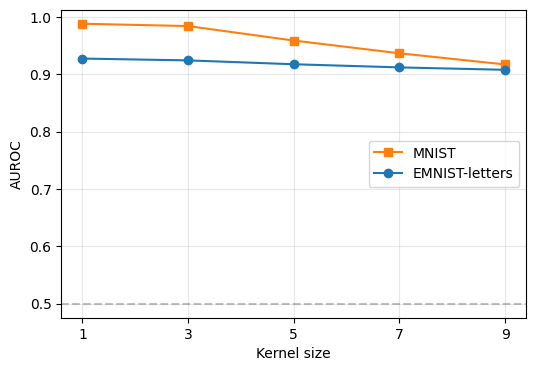

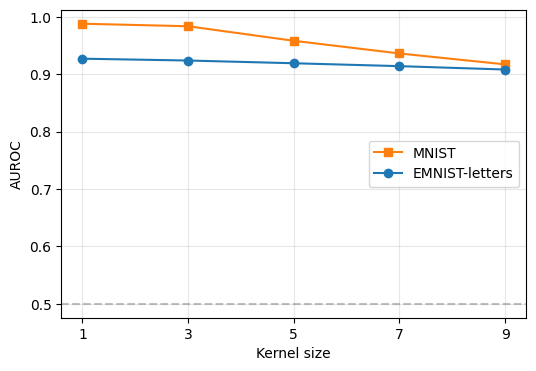

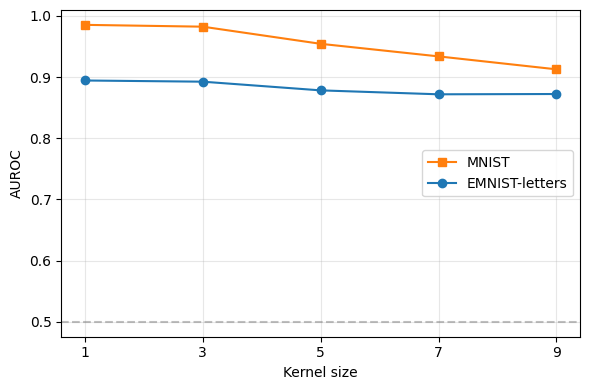

In [53]:
for (title, m_vals, e_vals) in [
    ('Total',     mnist_aurocs_tu, emnist_aurocs_tu),
    ('Aleatoric', mnist_aurocs_au, emnist_aurocs_au),
    ('Epistemic', mnist_aurocs_eu, emnist_aurocs_eu),
]:
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(kernel_sizes, m_vals, marker='s', color='C1', label='MNIST')
    ax.plot(kernel_sizes, e_vals, marker='o', color='C0', label='EMNIST-letters')
    ax.axhline(0.5, ls='--', color='gray', alpha=0.5)
    ax.set_xticks(kernel_sizes)
    ax.set_xlabel('Kernel size')
    ax.set_ylabel('AUROC')
    print(f'{title} Uncertainty')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# SCE (Static Calibration Error)

In [61]:
from utils.calibration import static_calibration_error, expected_calibration_error

T = 10
kernel_sizes = [1, 3, 5, 7, 9]

# --- EMNIST ---
emnist_eces, emnist_sces = [], []
for ks in kernel_sizes:
    print(f"Evaluating EMNIST with Gaussian blur (kernel size={ks})...")
    loader = get_dataloaders(
        data_dir="../data", batch_size=config.test_batch_size,
        num_workers=config.num_workers, use_cuda=torch.cuda.is_available(),
        dataset="EMNIST", dataset_kwargs={"split": "letters"},
        extra_transforms=[GaussianBlur(ks)]
    )[2]
    ece, _, _ = expected_calibration_error(emnist_model, loader, device, T=T, num_bins=26, num_classes=26)
    sce = static_calibration_error(emnist_model, loader, device, T=T, n_bins=26, num_classes=26)
    emnist_eces.append(ece)
    emnist_sces.append(sce)

# --- MNIST ---
mnist_eces, mnist_sces = [], []
for ks in kernel_sizes:
    print(f"Evaluating MNIST with Gaussian blur (kernel size={ks})...")
    loader = get_dataloaders(
        data_dir="../data", batch_size=config.test_batch_size,
        num_workers=config.num_workers, use_cuda=torch.cuda.is_available(),
        extra_transforms=[GaussianBlur(ks)]
    )[2]
    ece, _, _ = expected_calibration_error(mnist_model, loader, device, T=T, num_bins=10, num_classes=10)
    sce = static_calibration_error(mnist_model, loader, device, T=T, n_bins=10, num_classes=10)
    mnist_eces.append(ece)
    mnist_sces.append(sce)

Evaluating EMNIST with Gaussian blur (kernel size=1)...

Expected Calibration Error: 0.0101

Static Calibration Error: 0.001725
Evaluating EMNIST with Gaussian blur (kernel size=3)...

Expected Calibration Error: 0.0104

Static Calibration Error: 0.001912
Evaluating EMNIST with Gaussian blur (kernel size=5)...

Expected Calibration Error: 0.0133

Static Calibration Error: 0.002674
Evaluating EMNIST with Gaussian blur (kernel size=7)...

Expected Calibration Error: 0.0156

Static Calibration Error: 0.003595
Evaluating EMNIST with Gaussian blur (kernel size=9)...

Expected Calibration Error: 0.0142

Static Calibration Error: 0.004016
Evaluating MNIST with Gaussian blur (kernel size=1)...

Expected Calibration Error: 0.0013

Static Calibration Error: 0.001016
Evaluating MNIST with Gaussian blur (kernel size=3)...

Expected Calibration Error: 0.0012

Static Calibration Error: 0.001507
Evaluating MNIST with Gaussian blur (kernel size=5)...

Expected Calibration Error: 0.0051

Static Calibra

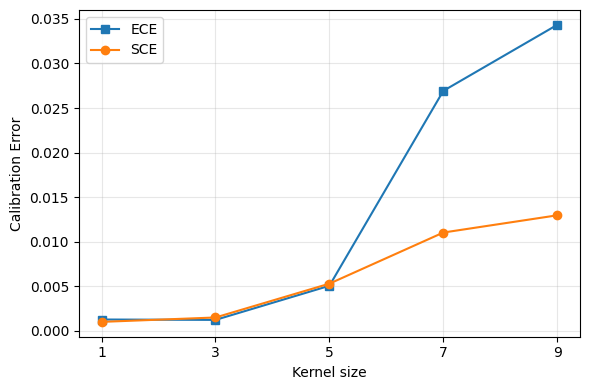

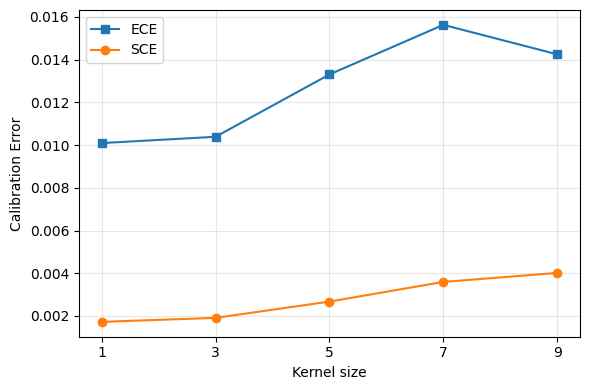

In [63]:
# MNIST
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(kernel_sizes, mnist_eces, marker='s', label='ECE')
ax.plot(kernel_sizes, mnist_sces, marker='o', label='SCE')
# ax.set_title('MNIST')
ax.set_xticks(kernel_sizes)
ax.set_xlabel('Kernel size')
ax.set_ylabel('Calibration Error')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# EMNIST
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(kernel_sizes, emnist_eces, marker='s', label='ECE')
ax.plot(kernel_sizes, emnist_sces, marker='o', label='SCE')
# ax.set_title('EMNIST-letters')
ax.set_xticks(kernel_sizes)
ax.set_xlabel('Kernel size')
ax.set_ylabel('Calibration Error')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Predictive NLL (MC-averaged)

In [4]:
from utils.calibration import mc_val_nll

T = 10
kernel_sizes = [1, 3, 5, 7, 9]

emnist_nlls = []
for ks in kernel_sizes:
    loader = get_dataloaders(
        data_dir="../data", batch_size=config.test_batch_size,
        num_workers=config.num_workers, use_cuda=torch.cuda.is_available(),
        dataset="EMNIST", dataset_kwargs={"split": "letters"},
        extra_transforms=[GaussianBlur(ks)]
    )[2]
    nll = mc_val_nll(emnist_model, loader, device, n_samples=T)
    emnist_nlls.append(nll)
    print(f"EMNIST blur={ks}: NLL = {nll:.4f}")

mnist_nlls = []
for ks in kernel_sizes:
    loader = get_dataloaders(
        data_dir="../data", batch_size=config.test_batch_size,
        num_workers=config.num_workers, use_cuda=torch.cuda.is_available(),
        extra_transforms=[GaussianBlur(ks)]
    )[2]
    nll = mc_val_nll(mnist_model, loader, device, n_samples=T)
    mnist_nlls.append(nll)
    print(f"MNIST  blur={ks}: NLL = {nll:.4f}")

EMNIST blur=1: NLL = 0.1985
EMNIST blur=3: NLL = 0.2076
EMNIST blur=5: NLL = 0.2431
EMNIST blur=7: NLL = 0.2931
EMNIST blur=9: NLL = 0.3345
MNIST  blur=1: NLL = 0.0319
MNIST  blur=3: NLL = 0.0412
MNIST  blur=5: NLL = 0.0941
MNIST  blur=7: NLL = 0.1987
MNIST  blur=9: NLL = 0.2720


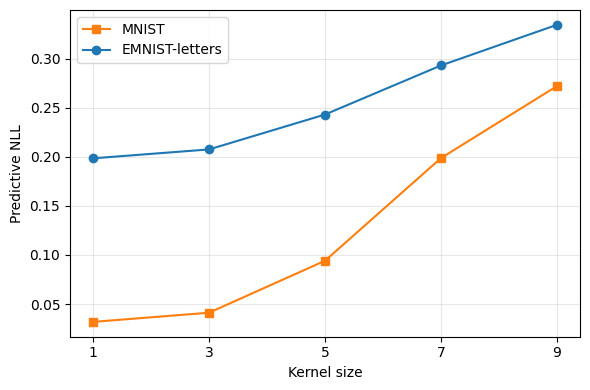

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = {'E': 'C0', 'M': 'C1'}
markers = {'E': 'o', 'M': 's'}
ax.plot(kernel_sizes, mnist_nlls, marker=markers['M'], color=colors['M'], label='MNIST')
ax.plot(kernel_sizes, emnist_nlls, marker=markers['E'], color=colors['E'], label='EMNIST-letters')
ax.set_xticks(kernel_sizes)
ax.set_xlabel('Kernel size')
ax.set_ylabel('Predictive NLL')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:

from utils.calibration import expected_calibration_error


@torch.no_grad()
def reliability_diagram(model, loader, device, T=20, n_bins=10, num_classes=10):
    ece, bin_conf, bin_acc = expected_calibration_error(model, loader, device, T, n_bins, num_classes)
    sce = static_calibration_error(model, loader, device, T, n_bins, num_classes)

    fig = plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect Calibration")
    plt.bar(bin_conf, bin_acc, width=0.05, alpha=0.3, edgecolor="black", label="Model")
    plt.plot(bin_conf, bin_acc, marker="o", color="blue")

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Reliability Diagram\nECE={ece:.4f}\nSCE={sce:.4f}")
    plt.legend()
    plt.grid(True)
    return fig



Expected Calibration Error: 0.0112

Static Calibration Error: 0.001859


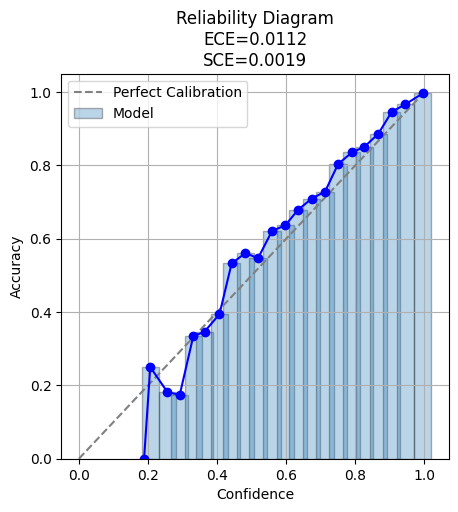

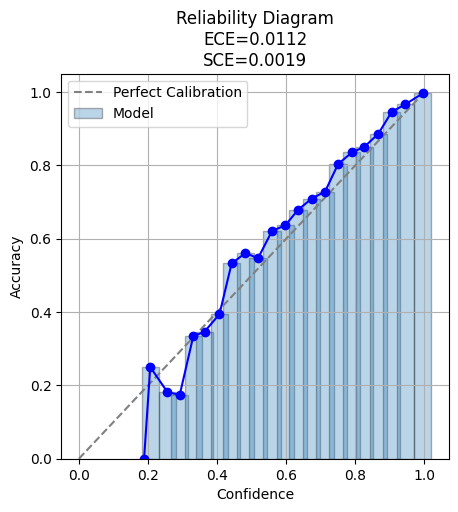

In [59]:
# reliability_diagram(mnist_model, mnist_test_loader, device, T=10, n_bins=10, num_classes=10)
reliability_diagram(emnist_model, emnist_test_loader, device, T=10, n_bins=26, num_classes=26)

# Пример изображений MNIST и EMNIST-letters с гауссовским размытием

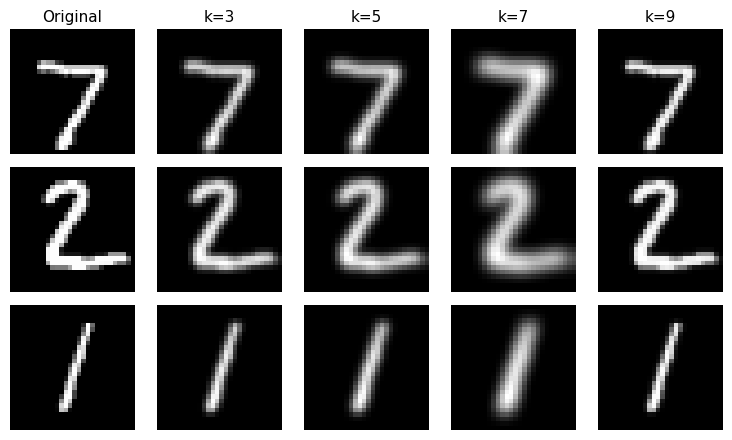

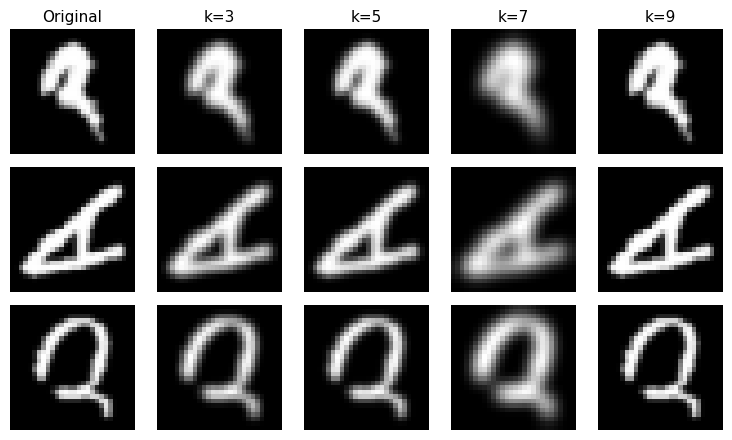

In [4]:
kernel_sizes = [1, 3, 5, 7, 9]
n_samples = 3

# --- MNIST ---
mnist_test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=n_samples,
    num_workers=0,
    use_cuda=False,
)[2]
mnist_batch, mnist_labels = next(iter(mnist_test_loader))

fig, axes = plt.subplots(n_samples, len(kernel_sizes), figsize=(len(kernel_sizes) * 1.5, n_samples * 1.5))
# fig.suptitle("MNIST — гауссовское размытие", fontsize=14, y=1.02)

for j, ks in enumerate(kernel_sizes):
    blur = GaussianBlur(ks) if ks > 1 else (lambda x: x)
    blurred = blur(mnist_batch)
    for i in range(n_samples):
        axes[i, j].imshow(blurred[i, 0], cmap='gray')
        axes[i, j].axis('off')
    title = f'k={ks}' if ks > 1 else 'Original'
    axes[0, j].set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

# --- EMNIST-letters ---
emnist_test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=n_samples,
    num_workers=0,
    use_cuda=False,
    dataset="EMNIST",
    dataset_kwargs={"split": "letters"},
)[2]
emnist_batch, emnist_labels = next(iter(emnist_test_loader))

fig, axes = plt.subplots(n_samples, len(kernel_sizes), figsize=(len(kernel_sizes) * 1.5, n_samples * 1.5))
for j, ks in enumerate(kernel_sizes):
    blur = GaussianBlur(ks) if ks > 1 else (lambda x: x)
    blurred = blur(emnist_batch)
    for i in range(n_samples):
        axes[i, j].imshow(blurred[i, 0], cmap='gray')
        axes[i, j].axis('off')
    title = f'k={ks}' if ks > 1 else 'Original'
    axes[0, j].set_title(title, fontsize=11)

plt.tight_layout()
plt.show()